In [23]:
!pip install pennylane

import time
import os
import copy

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, transforms

# Pennylane
import pennylane as qml
from pennylane import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# Plotting
import matplotlib.pyplot as plt


In [24]:
import torch
import random
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
from PIL import ImageFile

# Directories for training, validation, and test data
train_dir = '/kaggle/input/wildfire-prediction-dataset/train'
valid_dir = '/kaggle/input/wildfire-prediction-dataset/valid'
test_dir = '/kaggle/input/wildfire-prediction-dataset/test'

# Common image size and normalization for ResNet50V2
img_height, img_width = 224, 224  # ResNet50V2 expects 224x224 images
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_height, img_width)),
        transforms.ToTensor(),
        normalize
    ]),
    'validation': transforms.Compose([
        transforms.Resize((img_height, img_width)),
        transforms.ToTensor(),
        normalize
    ]),
    'test': transforms.Compose([
        transforms.Resize((img_height, img_width)),
        transforms.ToTensor(),
        normalize
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(train_dir, transform=data_transforms['train']),
    'validation': datasets.ImageFolder(valid_dir, transform=data_transforms['validation']),
    'test': datasets.ImageFolder(test_dir, transform=data_transforms['test']),
}

# Dataset sizes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation', 'test']}

# Class names
class_names = image_datasets['train'].classes

# Batch size
batch_size = 64

# Randomly sample 3000 indices from the training dataset
random.seed(42)  # For reproducibility
train_indices = random.sample(range(len(image_datasets['train'])), 200)
test_indices = random.sample(range(len(image_datasets['test'])), 200)
val_indices = random.sample(range(len(image_datasets['validation'])), 200)
                             

# Create subset for the sampled indices
train_subset = Subset(image_datasets['train'], train_indices)
test_subset = Subset(image_datasets['test'], test_indices)
val_subset = Subset(image_datasets['validation'], val_indices)
dataset_sizes['train'] = len(train_subset)
dataset_sizes['test'] = len(test_subset)
dataset_sizes['validation'] = len(val_subset)

# Initialize dataloaders
dataloaders = {
    'train': DataLoader(train_subset, batch_size=batch_size, shuffle=True),
    'validation': DataLoader(test_subset, batch_size=batch_size, shuffle=True),
    'test': DataLoader(val_subset, batch_size=batch_size, shuffle=False),
}

dataset_sizes

{'train': 200, 'validation': 200, 'test': 200}

In [25]:
print (dataset_sizes)


{'train': 200, 'validation': 200, 'test': 200}


In [37]:
n_qubits = 4                # Number of qubits
step = 0.0004               # Learning rate
batch_size = 4              # Number of samples for each training step
num_epochs = 3              # Number of training epochs
q_depth = 6                 # Depth of the quantum circuit (number of variational layers)
gamma_lr_scheduler = 0.1    # Learning rate reduction applied every 10 epochs.
q_delta = 0.01              # Initial spread of random quantum weights
start_time = time.time()    # Start of the computation timer

dev = qml.device("default.qubit", wires=n_qubits)


In [38]:
def H_layer(nqubits):
    """Layer of single-qubit Hadamard gates.
    """
    for idx in range(nqubits):
        qml.Hadamard(wires=idx)


def RY_layer(w):
    """Layer of parametrized qubit rotations around the y axis.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)


def entangling_layer(nqubits):
    """Layer of CNOTs followed by another shifted layer of CNOT.
    """
    # In other words it should apply something like :
    # CNOT  CNOT  CNOT  CNOT...  CNOT
    #   CNOT  CNOT  CNOT...  CNOT
    for i in range(0, nqubits - 1, 2):  # Loop over even indices: i=0,2,...N-2
        qml.CNOT(wires=[i, i + 1])
    for i in range(1, nqubits - 1, 2):  # Loop over odd indices:  i=1,3,...N-3
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def quantum_net(q_input_features, q_weights_flat):
    """
    The variational quantum circuit.
    """

    # Reshape weights
    q_weights = q_weights_flat.reshape(q_depth, n_qubits)

    # Start from state |+> , unbiased w.r.t. |0> and |1>
    H_layer(n_qubits)

    # Embed features in the quantum node
    RY_layer(q_input_features)

    # Sequence of trainable variational layers
    for k in range(q_depth):
        entangling_layer(n_qubits)
        RY_layer(q_weights[k])

    # Expectation values in the Z basis
    exp_vals = [qml.expval(qml.PauliZ(position)) for position in range(n_qubits)]
    return tuple(exp_vals)

In [39]:
class DressedQuantumNet(nn.Module):
    """
    Torch module implementing the *dressed* quantum net.
    """

    def __init__(self):
        """
        Definition of the *dressed* layout.
        """

        super().__init__()
        self.pre_net = nn.Linear(512, n_qubits)
        self.q_params = nn.Parameter(q_delta * torch.randn(q_depth * n_qubits))
        self.post_net = nn.Linear(n_qubits, 2)

    def forward(self, input_features):
        """
        Defining how tensors are supposed to move through the *dressed* quantum
        net.
        """

        # obtain the input features for the quantum circuit
        # by reducing the feature dimension from 512 to 4
        pre_out = self.pre_net(input_features)
        q_in = torch.tanh(pre_out) * np.pi / 2.0

        # Apply the quantum circuit to each element of the batch and append to q_out
        q_out = torch.Tensor(0, n_qubits)
        q_out = q_out.to(device)
        for elem in q_in:
            q_out_elem = torch.hstack(quantum_net(elem, self.q_params)).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem))

        # return the two-dimensional prediction from the postprocessing layer
        return self.post_net(q_out)


In [40]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
model_hybrid = torchvision.models.resnet18(weights=weights)

for param in model_hybrid.parameters():
    param.requires_grad = False


# Notice that model_hybrid.fc is the last layer of ResNet18
model_hybrid.fc = DressedQuantumNet()

# Use CUDA or CPU according to the "device" object.
model_hybrid = model_hybrid.to(device)

In [41]:
criterion = nn.CrossEntropyLoss()

In [42]:
optimizer_hybrid = optim.Adam(model_hybrid.fc.parameters(), lr=step)

In [43]:
exp_lr_scheduler = lr_scheduler.StepLR(
    optimizer_hybrid, step_size=10, gamma=gamma_lr_scheduler
)

In [46]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = 10000.0  # Large arbitrary number
    best_acc_train = 0.0
    best_loss_train = 10000.0  # Large arbitrary number
    print("Training started:")
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):

        # Each epoch has a training and validation phase
        for phase in ["train", "validation"]:
            if phase == "train":
                # Set model to training mode
                model.train()
            else:
                # Set model to evaluate mode
                model.eval()
            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            n_batches = dataset_sizes[phase] // batch_size
            it = 0
            for inputs, labels in dataloaders[phase]:
                since_batch = time.time()
                batch_size_ = len(inputs)
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                # Track/compute gradient and make an optimization step only when training
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                # Print iteration results
                running_loss += loss.item() * batch_size_
                batch_corrects = torch.sum(preds == labels.data).item()
                running_corrects += batch_corrects
                print(
                    "Phase: {} Epoch: {}/{} Iter: {}/{} Batch time: {:.4f}".format(
                        phase,
                        epoch + 1,
                        num_epochs,
                        it + 1,
                        n_batches + 1,
                        time.time() - since_batch,
                    ),
                    end="\r",
                    flush=True,
                )
                it += 1

            # Print epoch results
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            print(
                "Phase: {} Epoch: {}/{} Loss: {:.4f} Acc: {:.4f}        ".format(
                    "train" if phase == "train" else "validation  ",
                    epoch + 1,
                    num_epochs,
                    epoch_loss,
                    epoch_acc,
                )
            )

            # Check if this is the best model wrt previous epochs
            if phase == "validation" and epoch_acc > best_acc:
                val_accuracies.append(epoch_acc)
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == "validation" and epoch_loss < best_loss:
                val_losses.append (epoch_loss)
                best_loss = epoch_loss
            if phase == "train" and epoch_acc > best_acc_train:
                train_accuracies.append (epoch_acc)
                best_acc_train = epoch_acc
            if phase == "train" and epoch_loss < best_loss_train:
                train_losses.append(epoch_loss)
                best_loss_train = epoch_loss

            # Update learning rate
            if phase == "train":
                scheduler.step()

    # Print final results
    model.load_state_dict(best_model_wts)
    time_elapsed = time.time() - since
    print(
        "Training completed in {:.0f}m {:.0f}s".format(time_elapsed // 60, time_elapsed % 60)
    )
    print("Best test loss: {:.4f} | Best test accuracy: {:.4f}".format(best_loss, best_acc))
    
    epochs_range = range(1, num_epochs + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Training Loss')
    plt.plot(epochs_range, val_losses, label='Validation Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
    plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return model

Training started:
Phase: train Epoch: 1/3 Loss: 0.5375 Acc: 0.7900        
Phase: validation   Epoch: 1/3 Loss: 0.5044 Acc: 0.8000        
Phase: train Epoch: 2/3 Loss: 0.4838 Acc: 0.8350        
Phase: validation   Epoch: 2/3 Loss: 0.4672 Acc: 0.8250        
Phase: train Epoch: 3/3 Loss: 0.4474 Acc: 0.8750        
Phase: validation   Epoch: 3/3 Loss: 0.4404 Acc: 0.8500        
Training completed in 1m 47s
Best test loss: 0.4404 | Best test accuracy: 0.8500


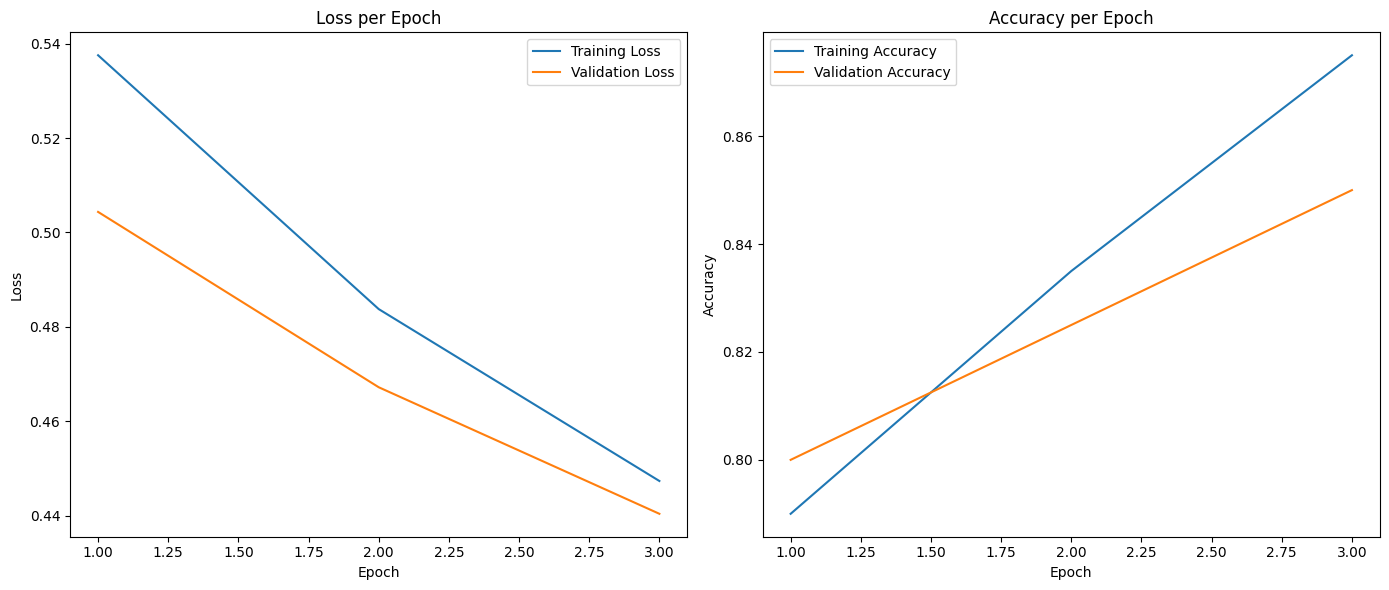

In [47]:
model_hybrid = train_model(
    model_hybrid, criterion, optimizer_hybrid, exp_lr_scheduler, num_epochs=num_epochs
)